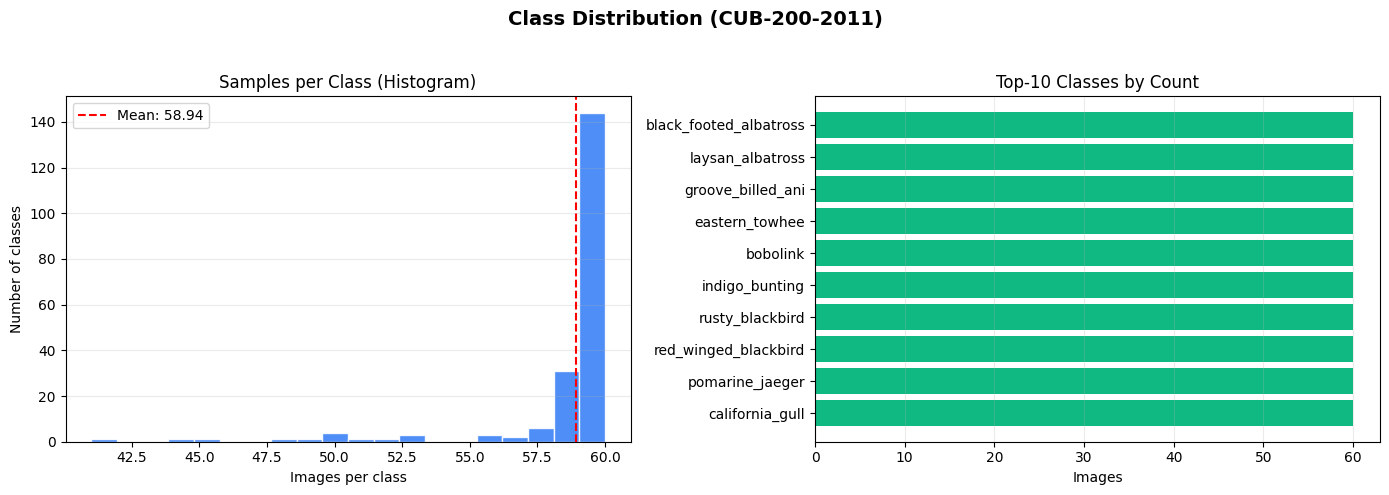

Class Distribution Summary
Total images: 11,788
Total classes: 200
Mean per class: 58.94
Std per class: 2.92
Min/Max per class: 41 / 60

Conclusion (Class Distribution):
- Class distribution is reasonably balanced (max/min ratio = 1.46).
- This is generally suitable for classification training without heavy class-reweighting.


In [1]:
"""CUB Classification - Class Distribution Analysis"""
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

data_dir = Path("data/CUB_200_2011")
labels_path = data_dir / "image_class_labels.txt"
classes_path = data_dir / "classes.txt"

if not labels_path.exists():
    raise FileNotFoundError(f"Missing file: {labels_path}")
if not classes_path.exists():
    raise FileNotFoundError(f"Missing file: {classes_path}")

labels_df = pd.read_csv(labels_path, sep="\s+", header=None, names=["image_idx", "class_idx"] )
classes_df = pd.read_csv(classes_path, sep=" ", header=None, names=["class_idx", "class_name"], engine="python")

class_counts = labels_df["class_idx"].value_counts().sort_index()
class_stats = class_counts.describe()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Class Distribution (CUB-200-2011)", fontsize=14, fontweight="bold")

axes[0].hist(class_counts.values, bins=20, color="#3b82f6", edgecolor="white", alpha=0.9)
axes[0].axvline(class_counts.mean(), color="red", linestyle="--", label=f"Mean: {class_counts.mean():.2f}")
axes[0].set_title("Samples per Class (Histogram)")
axes[0].set_xlabel("Images per class")
axes[0].set_ylabel("Number of classes")
axes[0].grid(axis="y", alpha=0.25)
axes[0].legend()

top_classes = class_counts.sort_values(ascending=False).head(10)
top_labels = [classes_df.loc[classes_df["class_idx"] == i, "class_name"].values[0] for i in top_classes.index]
axes[1].barh(top_labels[::-1], top_classes.values[::-1], color="#10b981")
axes[1].set_title("Top-10 Classes by Count")
axes[1].set_xlabel("Images")
axes[1].grid(axis="x", alpha=0.25)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("Class Distribution Summary")
print("=" * 70)
print(f"Total images: {len(labels_df):,}")
print(f"Total classes: {class_counts.shape[0]}")
print(f"Mean per class: {class_stats['mean']:.2f}")
print(f"Std per class: {class_stats['std']:.2f}")
print(f"Min/Max per class: {int(class_stats['min'])} / {int(class_stats['max'])}")

# Conclusion (Part 1)
imbalance_ratio = class_stats['max'] / max(class_stats['min'], 1)
if imbalance_ratio <= 1.2:
    verdict = "very balanced"
elif imbalance_ratio <= 1.5:
    verdict = "reasonably balanced"
else:
    verdict = "noticeably imbalanced"

print("\nConclusion (Class Distribution):")
print(f"- Class distribution is {verdict} (max/min ratio = {imbalance_ratio:.2f}).")
print("- This is generally suitable for classification training without heavy class-reweighting.")

## Remark - Part 1 (Class Distribution)
- The class histogram is fairly even, and the max/min gap is limited compared with many fine-grained datasets.
- This balance is a good signal for stable classifier training and more reliable macro-level metrics.
- A standard training pipeline should work well here without aggressive class reweighting.

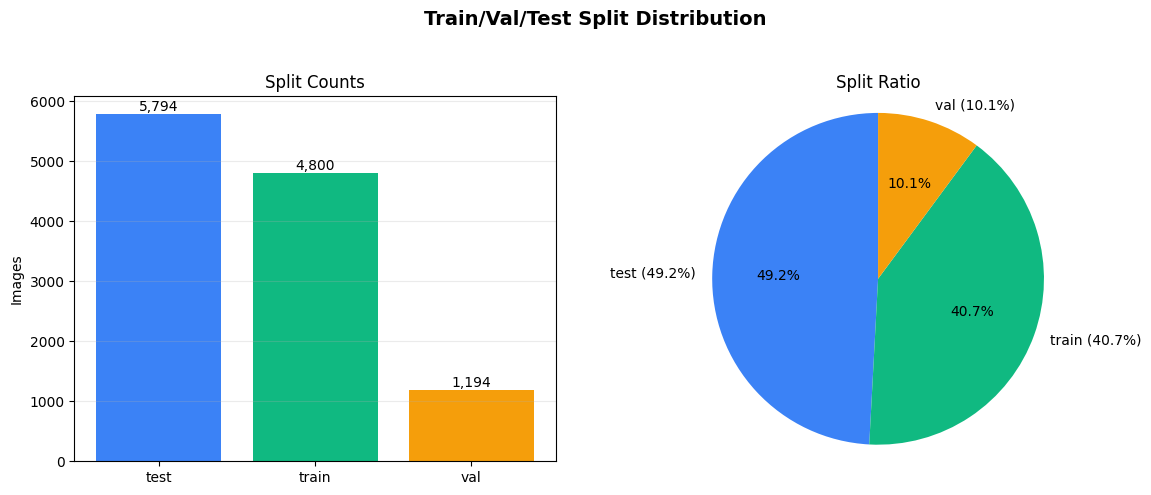

Split Distribution Summary
Split file used: data\CUB_200_2011\train_val_test_split.txt
- test: 5,794 images (49.15%)
- train: 4,800 images (40.72%)
- val: 1,194 images (10.13%)

Conclusion (Split Distribution):
- Split proportions look practical for model development and evaluation.
- Keep evaluation on test split strictly separated to avoid leakage.


In [2]:
"""CUB Classification - Train/Val/Test Split Distribution"""
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

data_dir = Path("data/CUB_200_2011")
candidate_split_files = [
    data_dir / "train_val_test_split.txt",
    data_dir / "train_test_split.txt",
    data_dir / "train_val_split.txt",
]
split_path = next((p for p in candidate_split_files if p.exists()), None)
if split_path is None:
    raise FileNotFoundError(
    "Could not find split file. Expected one of: " + ", ".join(str(p) for p in candidate_split_files)
    )

split_df = pd.read_csv(split_path, sep="\s+", header=None, names=["image_idx", "split"])
split_df["split"] = split_df["split"].astype(str).str.lower()

# Normalize common numeric conventions when needed.
if set(split_df["split"].unique()).issubset({"0", "1"}):
    split_df["split"] = split_df["split"].map({"0": "test", "1": "train"}).fillna(split_df["split"] )

split_counts = split_df["split"].value_counts()
split_ratio = split_counts / split_counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Train/Val/Test Split Distribution", fontsize=14, fontweight="bold")

axes[0].bar(split_counts.index, split_counts.values, color=["#3b82f6", "#10b981", "#f59e0b"][: len(split_counts)])
for i, v in enumerate(split_counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")
axes[0].set_title("Split Counts")
axes[0].set_ylabel("Images")
axes[0].grid(axis="y", alpha=0.25)

axes[1].pie(
    split_counts.values,
    labels=[f"{k} ({split_ratio[k]*100:.1f}%)" for k in split_counts.index],
    autopct="%.1f%%",
    startangle=90,
    colors=["#3b82f6", "#10b981", "#f59e0b"][: len(split_counts)],
)
axes[1].set_title("Split Ratio")
axes[1].axis("equal")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("Split Distribution Summary")
print("=" * 70)
print(f"Split file used: {split_path}")
for name, cnt in split_counts.items():
    print(f"- {name}: {cnt:,} images ({split_ratio[name]*100:.2f}%)")

# Conclusion (Part 2)
if "val" in split_counts.index and split_ratio.get("val", 0.0) < 0.1:
    split_note = "Validation set is relatively small; metrics may be noisier."
else:
    split_note = "Split proportions look practical for model development and evaluation."

print("\nConclusion (Split Distribution):")
print(f"- {split_note}")
print("- Keep evaluation on test split strictly separated to avoid leakage.")

## Remark - Part 2 (Split Distribution)
- The split proportions are practical for training and evaluation, with enough samples for meaningful testing.
- Keep model selection strictly on train/validation and reserve test only for final reporting.
- If validation remains small, use repeated runs or cross-validation to reduce variance in reported results.

C:\Users\USER\AppData\Local\Temp\ipykernel_15488\2393987327.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.02, 0.08, 0.98, 0.95])


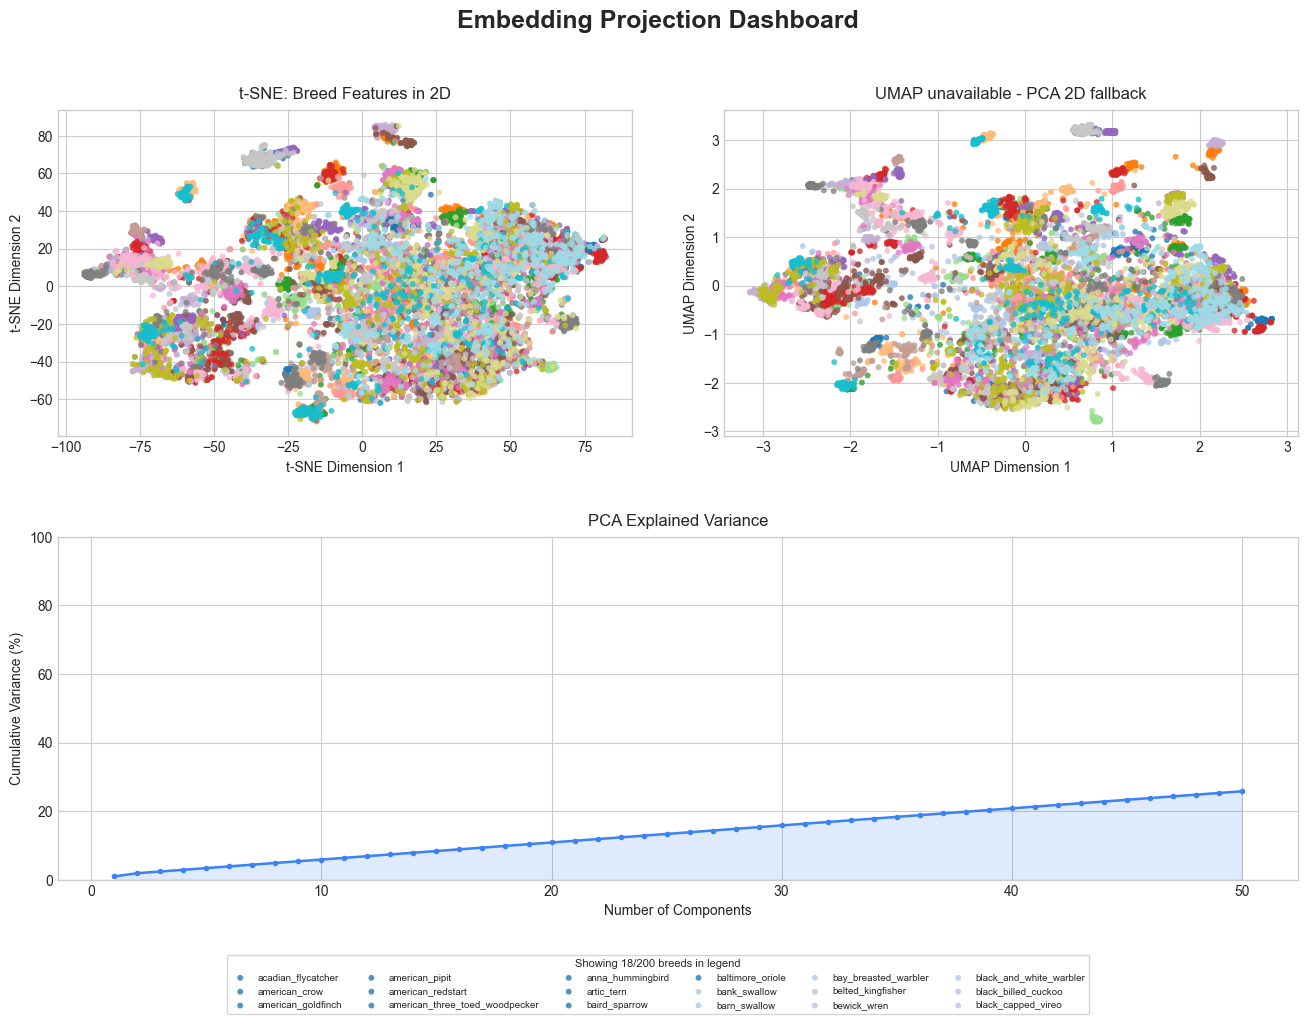

Embedding Analysis Summary
Source CSV: csv\tsne_embeddings.csv
Rows: 11,788 | Unique breeds: 200
UMAP backend: PCA fallback
Cumulative variance at 10 components: 5.90%
Cumulative variance at 50 components: 25.81%


In [6]:
"""CUB Classification - Embedding Analysis (t-SNE / UMAP / PCA Variance)"""
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Try to import UMAP. If unavailable, fallback to PCA-2D for the second panel.
try:
    from umap import UMAP
    HAS_UMAP = True
except Exception:
    HAS_UMAP = False

csv_path = Path("csv/tsne_embeddings.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"Missing file: {csv_path}")

df = pd.read_csv(csv_path)
required_cols = {"image_name", "breed", "tsne_x", "tsne_y"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns in {csv_path}: {sorted(missing)}")

df = df.dropna(subset=["breed", "tsne_x", "tsne_y"]).copy()
df["breed"] = df["breed"].astype(str)

# Build feature matrix from available columns (t-SNE coords + breed one-hot).
breed_ohe = pd.get_dummies(df["breed"], dtype=float)
X = np.concatenate([df[["tsne_x", "tsne_y"]].to_numpy(dtype=float), breed_ohe.to_numpy(dtype=float)], axis=1)
X_scaled = StandardScaler().fit_transform(X)

if HAS_UMAP:
    reducer = UMAP(n_components=2, n_neighbors=30, min_dist=0.1, metric="euclidean", random_state=42)
    umap_xy = reducer.fit_transform(X_scaled)
    umap_title = "UMAP: Breed Features in 2D"
else:
    umap_xy = PCA(n_components=2, random_state=42).fit_transform(X_scaled)
    umap_title = "UMAP unavailable - PCA 2D fallback"

df["umap_x"] = umap_xy[:, 0]
df["umap_y"] = umap_xy[:, 1]

max_components = min(50, X_scaled.shape[0], X_scaled.shape[1])
if max_components < 2:
    raise ValueError("Not enough data to compute PCA explained variance.")

pca = PCA(n_components=max_components, random_state=42)
pca.fit(X_scaled)
cum_var = np.cumsum(pca.explained_variance_ratio_) * 100
comp_idx = np.arange(1, max_components + 1)

breeds = sorted(df["breed"].unique())
cmap = plt.get_cmap("tab20", len(breeds))

plt.style.use("seaborn-v0_8-whitegrid")
fig = plt.figure(figsize=(16, 10))
gs = GridSpec(2, 2, figure=fig, height_ratios=[1, 1.05], hspace=0.30, wspace=0.16)

ax_tsne = fig.add_subplot(gs[0, 0])
ax_umap = fig.add_subplot(gs[0, 1])
ax_pca = fig.add_subplot(gs[1, :])

legend_handles = []
legend_labels = []
legend_limit = 18

for i, breed in enumerate(breeds):
    part = df[df["breed"] == breed]
    color = cmap(i)

    h = ax_tsne.scatter(
        part["tsne_x"],
        part["tsne_y"],
        s=18,
        alpha=0.78,
        color=color,
        edgecolors="none",
    )

    ax_umap.scatter(
        part["umap_x"],
        part["umap_y"],
        s=18,
        alpha=0.78,
        color=color,
        edgecolors="none",
    )

    if i < legend_limit:
        legend_handles.append(h)
        legend_labels.append(breed)

ax_tsne.set_title("t-SNE: Breed Features in 2D", fontsize=12, pad=8)
ax_tsne.set_xlabel("t-SNE Dimension 1")
ax_tsne.set_ylabel("t-SNE Dimension 2")

ax_umap.set_title(umap_title, fontsize=12, pad=8)
ax_umap.set_xlabel("UMAP Dimension 1")
ax_umap.set_ylabel("UMAP Dimension 2")

ax_pca.plot(comp_idx, cum_var, marker="o", markersize=3, linewidth=1.8, color="#3b82f6")
ax_pca.fill_between(comp_idx, cum_var, color="#3b82f6", alpha=0.16)
ax_pca.set_title("PCA Explained Variance", fontsize=12, pad=8)
ax_pca.set_xlabel("Number of Components")
ax_pca.set_ylabel("Cumulative Variance (%)")
ax_pca.set_ylim(0, 100)

# Compact legend: show sample breeds only to keep layout clean.
legend_note = f"Showing {legend_limit}/{len(breeds)} breeds in legend"
fig.legend(
    legend_handles,
    legend_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.04),
    ncol=6,
    fontsize=7,
    frameon=True,
    title=legend_note,
    title_fontsize=8,
 )

fig.suptitle("Embedding Projection Dashboard", fontsize=18, fontweight="bold", y=0.98)
plt.tight_layout(rect=[0.02, 0.08, 0.98, 0.95])
plt.show()

print("Embedding Analysis Summary")
print("=" * 80)
print(f"Source CSV: {csv_path}")
print(f"Rows: {len(df):,} | Unique breeds: {df['breed'].nunique()}")
print(f"UMAP backend: {'umap-learn' if HAS_UMAP else 'PCA fallback'}")
print(f"Cumulative variance at 10 components: {cum_var[min(9, len(cum_var)-1)]:.2f}%")
print(f"Cumulative variance at {max_components} components: {cum_var[-1]:.2f}%")

## Remark - Part 3 (Embedding Projections)
- The t-SNE/UMAP structure shows several local clusters but still noticeable overlap between similar bird breeds.
- This indicates feature separability is present but fine-grained confusion is expected for visually close species.
- Better backbone features or metric-learning objectives could improve inter-breed margins.

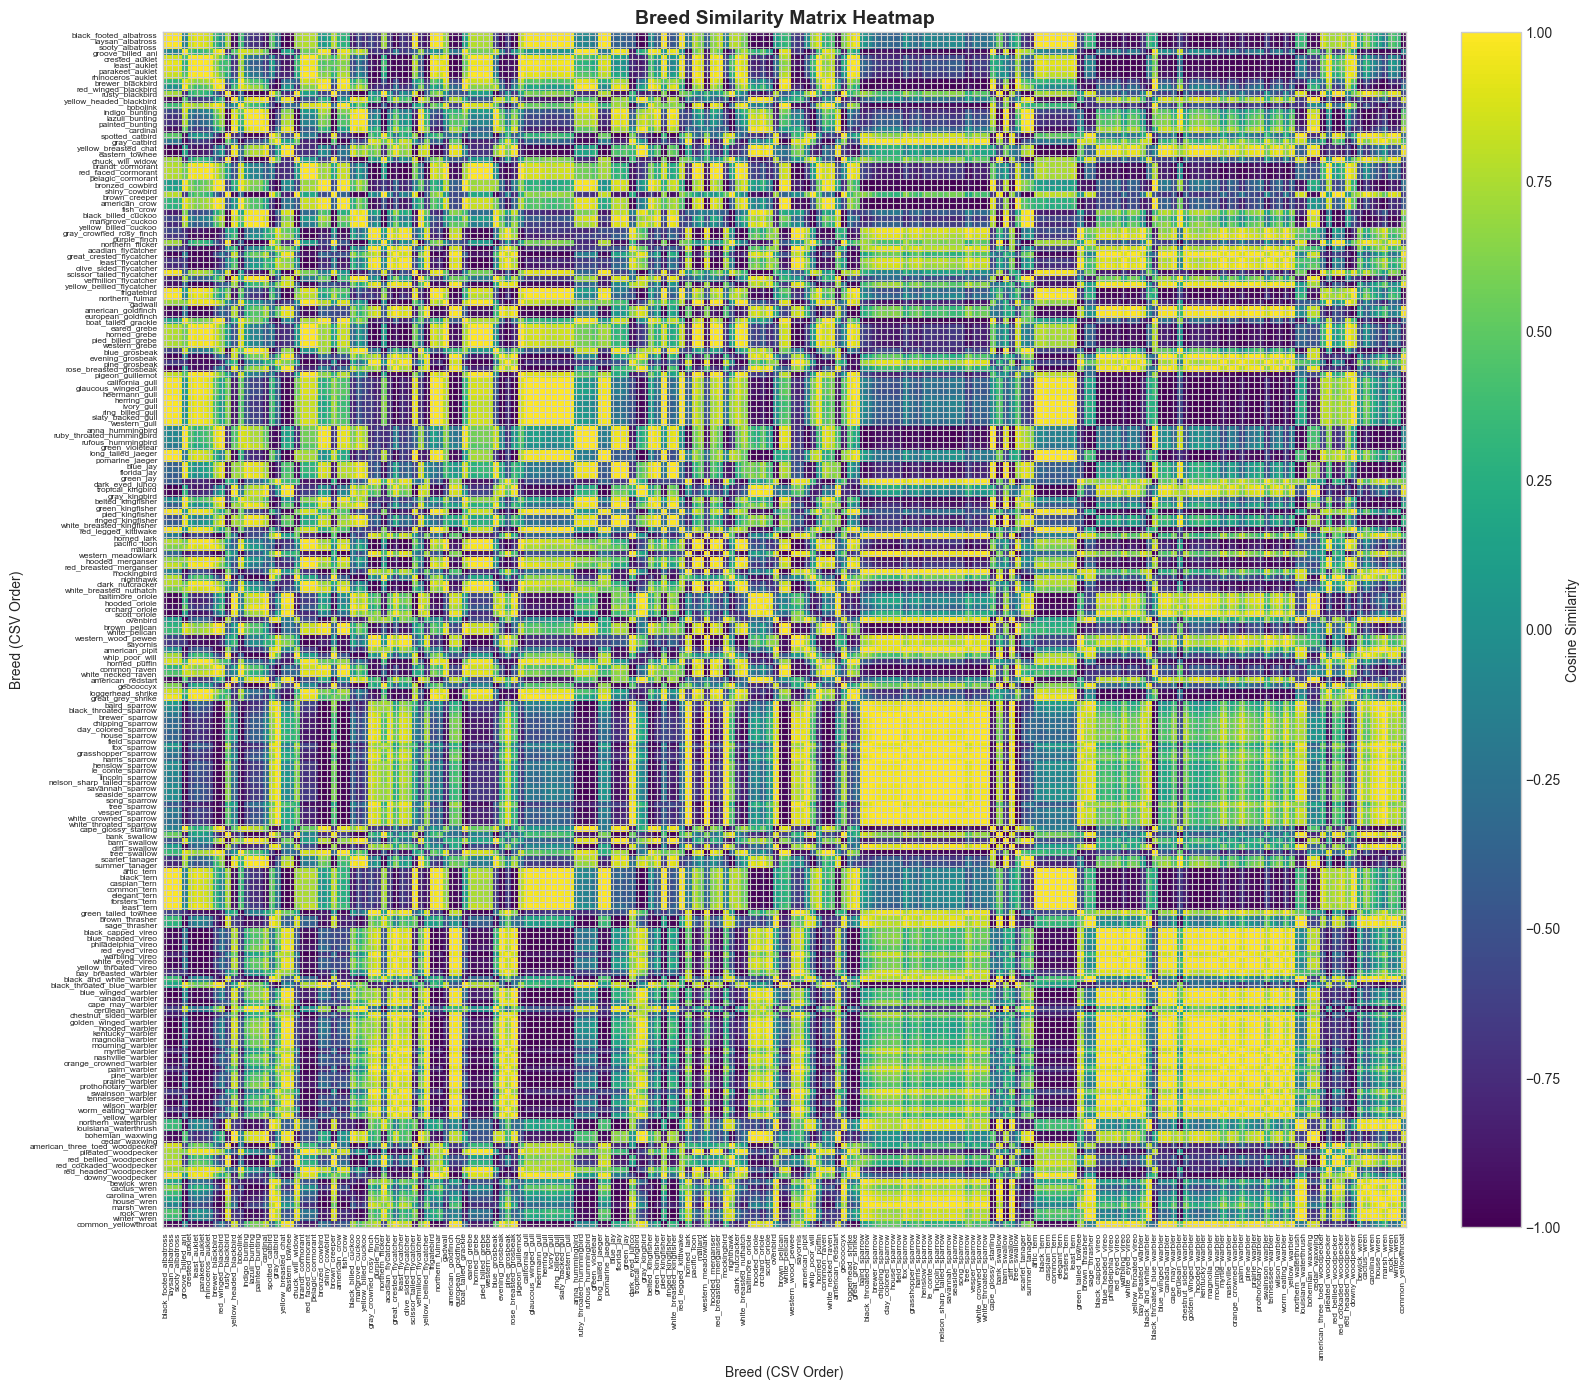

Breed Similarity Summary
Source CSV: csv\similarity_matrix.csv
Matrix size: 200 x 200
Top-10 most similar breed pairs from this matrix:
- american_crow <-> brown_pelican: 1.0000
- brown_pelican <-> american_crow: 1.0000
- pacific_loon <-> horned_grebe: 1.0000
- horned_grebe <-> pacific_loon: 1.0000
- red_faced_cormorant <-> horned_grebe: 1.0000
- horned_grebe <-> red_faced_cormorant: 1.0000
- pacific_loon <-> red_faced_cormorant: 1.0000
- red_faced_cormorant <-> pacific_loon: 1.0000
- white_throated_sparrow <-> white_crowned_sparrow: 1.0000
- white_crowned_sparrow <-> white_throated_sparrow: 1.0000


In [12]:
"""CUB Classification - Breed Similarity Matrix Heatmap (from CSV)"""
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

csv_path = Path("csv/similarity_matrix.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"Missing file: {csv_path}")

# Keep row/column order exactly as provided in CSV.
sim_df = pd.read_csv(csv_path, index_col=0)
sim_df.index = sim_df.index.astype(str)
sim_df.columns = sim_df.columns.astype(str)

# Align columns to row order when possible.
missing_cols = [b for b in sim_df.index if b not in sim_df.columns]
if missing_cols:
    raise ValueError(
        "Some row breeds are missing in columns: " + ", ".join(missing_cols[:10])
        + (" ..." if len(missing_cols) > 10 else "")
    )
sim_df = sim_df.loc[sim_df.index, sim_df.index]

# Convert to numeric and validate.
sim_df = sim_df.apply(pd.to_numeric, errors="coerce")
if sim_df.isna().any().any():
    raise ValueError("Similarity matrix contains non-numeric or NaN values.")

fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(sim_df.values, cmap="viridis", vmin=-1, vmax=1, aspect="auto")

ax.set_title("Breed Similarity Matrix Heatmap", fontsize=14, fontweight="bold")
ax.set_xticks(np.arange(sim_df.shape[1]))
ax.set_yticks(np.arange(sim_df.shape[0]))
ax.set_xticklabels(sim_df.columns, rotation=90, fontsize=6)
ax.set_yticklabels(sim_df.index, fontsize=6)
ax.set_xlabel("Breed (CSV Order)")
ax.set_ylabel("Breed (CSV Order)")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Cosine Similarity", rotation=90)

plt.tight_layout()
plt.show()

# Summary using the provided matrix directly.
pairs_long = (
    sim_df.rename_axis(index="breed_1", columns="breed_2")
    .stack()
    .rename("similarity")
    .reset_index()
)
pairs_long = pairs_long[pairs_long["breed_1"] != pairs_long["breed_2"]]
pairs_long = pairs_long.sort_values("similarity", ascending=False).head(10)

print("Breed Similarity Summary")
print("=" * 80)
print(f"Source CSV: {csv_path}")
print(f"Matrix size: {sim_df.shape[0]} x {sim_df.shape[1]}")
print("Top-10 most similar breed pairs from this matrix:")
for _, row in pairs_long.iterrows():
    print(f"- {row['breed_1']} <-> {row['breed_2']}: {row['similarity']:.4f}")

## Remark - Part 4 (Breed Similarity Heatmap)
- Bright blocks indicate groups of breeds with very close centroid behavior in embedding space.
- These highly similar pairs are likely hard negatives and should be monitored in confusion matrices.
- Targeted augmentation and hard-negative mining on these groups can improve fine-grained classification robustness.